In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable

# ─── Transformations ────────────────────────────────────────────────────────

def apply_warm_tone(pixels: torch.Tensor) -> torch.Tensor:
    warm = pixels.clone()
    warm[:, 0] = torch.clamp(pixels[:, 0] * 1.2,  0, 1)
    warm[:, 1] = torch.clamp(pixels[:, 1] * 1.05, 0, 1)
    warm[:, 2] = torch.clamp(pixels[:, 2] * 0.7,  0, 1)
    return warm

def apply_grayscale(pixels: torch.Tensor) -> torch.Tensor:
    luma = 0.2126 * pixels[:, 0] + 0.7152 * pixels[:, 1] + 0.0722 * pixels[:, 2]
    return luma.unsqueeze(1).repeat(1, 3)

def apply_sepia(pixels: torch.Tensor) -> torch.Tensor:
    r = torch.clamp(pixels[:, 0] * 0.393 + pixels[:, 1] * 0.769 + pixels[:, 2] * 0.189, 0, 1)
    g = torch.clamp(pixels[:, 0] * 0.349 + pixels[:, 1] * 0.686 + pixels[:, 2] * 0.168, 0, 1)
    b = torch.clamp(pixels[:, 0] * 0.272 + pixels[:, 1] * 0.534 + pixels[:, 2] * 0.131, 0, 1)
    return torch.stack([r, g, b], dim=1)

def apply_reinhard(pixels: torch.Tensor) -> torch.Tensor:
    return pixels / (1 + pixels)

def apply_invert(pixels: torch.Tensor) -> torch.Tensor:
    return 1.0 - pixels

def apply_gamma(pixels: torch.Tensor, gamma: float = 2.2) -> torch.Tensor:
    return torch.clamp(pixels ** (1.0 / gamma), 0, 1)

# Maps name → function for easy selection
TRANSFORMATIONS: dict[str, Callable] = {
    "warm_tone": apply_warm_tone,
    "grayscale": apply_grayscale,
    "sepia":     apply_sepia,
    "reinhard":  apply_reinhard,
    "invert":    apply_invert,
    "gamma":     apply_gamma,
}

# ─── Model ──────────────────────────────────────────────────────────────────

class ColorMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 3),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# ─── Data ───────────────────────────────────────────────────────────────────

def load_image_as_pixels(path: str) -> torch.Tensor:
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32) / 255.0
    return torch.from_numpy(arr.reshape(-1, 3))

def make_dataset(
    transform: Callable,
    num_samples: int = 100_000
) -> tuple[torch.Tensor, torch.Tensor]:
    pixels = torch.rand(num_samples, 3)
    return pixels, transform(pixels)

# ─── Training ───────────────────────────────────────────────────────────────

def train(
    transform: Callable,
    epochs: int = 500,
    num_samples: int = 100_000,
    batch_size: int = 1024,
    lr: float = 1e-3,
) -> ColorMLP:
    pixels, targets = make_dataset(transform, num_samples)

    model = ColorMLP()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(pixels, targets),
        batch_size=batch_size,
        shuffle=True
    )

    for epoch in range(epochs):
        total_loss = 0.0
        for batch_pixels, batch_targets in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(batch_pixels), batch_targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if epoch % 50 == 0:
            print(f"Epoch {epoch:4d} — avg loss: {total_loss / len(loader):.6f}")

    return model

# ─── Visualization ──────────────────────────────────────────────────────────

def plot_comparison(
    model: ColorMLP,
    transform: Callable,
    image_path: str,
    transform_name: str = "Analytical"
) -> None:
    pixels = load_image_as_pixels(image_path)
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    with torch.no_grad():
        model_out = (model(pixels).numpy() * 255).astype(np.uint8).reshape(h, w, 3)

    analytical = (transform(pixels).numpy() * 255).astype(np.uint8).reshape(h, w, 3)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    ax1.imshow(np.array(img));       ax1.set_title("Original");                ax1.axis("off")
    ax2.imshow(analytical);          ax2.set_title(transform_name);            ax2.axis("off")
    ax3.imshow(model_out);           ax3.set_title("Model output");            ax3.axis("off")

    plt.tight_layout()
    plt.show()

def export_onnx(model: ColorMLP, out_path: str):
    model.eval()
    dummy = torch.zeros(1, 3)
    torch.onnx.export(
        model,
        dummy,
        out_path,
        input_names=["pixels"],
        output_names=["result"],
        dynamic_axes={"pixels": {0: "num_pixels"}, "result": {0: "num_pixels"}},
        opset_version=11,
        dynamo=False   # force legacy exporter
    )
    print(f"Exported to {out_path}")

In [6]:
transform = TRANSFORMATIONS["sepia"]

model = train(transform, epochs=400, num_samples=10000)

Epoch    0 — avg loss: 0.071625
Epoch   50 — avg loss: 0.006010
Epoch  100 — avg loss: 0.000710
Epoch  150 — avg loss: 0.000562
Epoch  200 — avg loss: 0.000543
Epoch  250 — avg loss: 0.000539
Epoch  300 — avg loss: 0.000533
Epoch  350 — avg loss: 0.000530


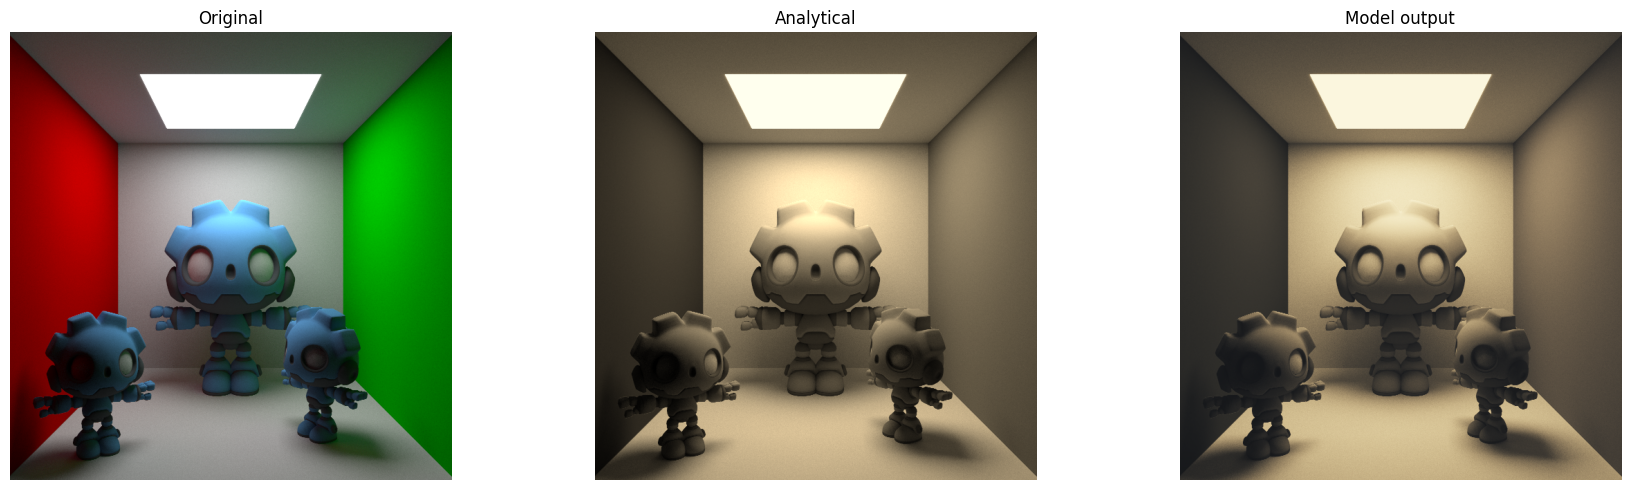

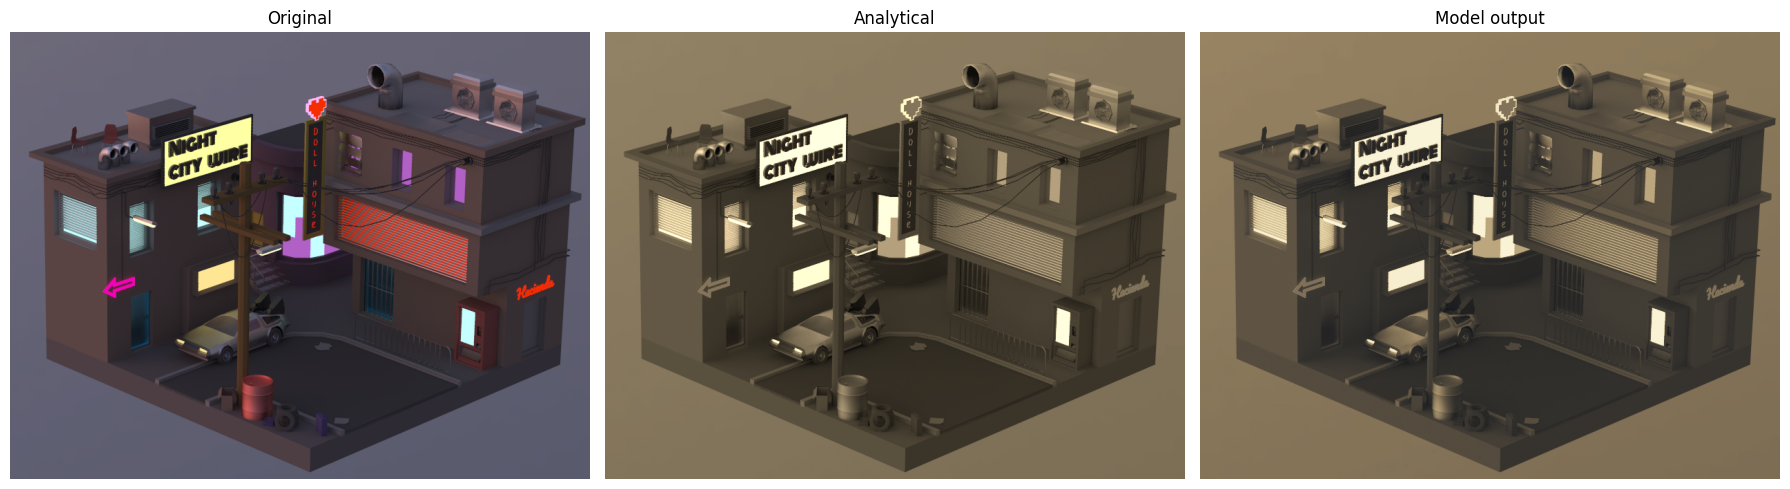

In [7]:
images = [
    "gobots.png",
    "city.png"
]

for image in images:
    plot_comparison(model, transform, f"../images/{image}")

In [8]:
export_onnx(model, "../models/color_mlp.onnx")

Exported to ../models/color_mlp.onnx


/tmp/ipykernel_25143/3719877062.py:140: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [12]:
import onnx

model = onnx.load("../models/color_mlp.onnx")
graph = model.graph

print("── Inputs ──")
for inp in graph.input:
    print(f"  {inp.name}: {[d.dim_value for d in inp.type.tensor_type.shape.dim]}")

print("\n── Nodes ──")
for node in graph.node:
    print(f"  op: {node.op_type}")
    print(f"    inputs:  {list(node.input)}")
    print(f"    outputs: {list(node.output)}")
    for attr in node.attribute:
        print(f"    attr: {str(attr).replace('\n', ' ')}")

print("\n── Initializers (weights) ──")
for init in graph.initializer:
    print(f"  {init.name}: shape {list(init.dims)}")

print("\n── Outputs ──")
for out in graph.output:
    print(f"  {out.name}")

── Inputs ──
  pixels: [0, 3]

── Nodes ──
  op: Gemm
    inputs:  ['pixels', 'net.0.weight', 'net.0.bias']
    outputs: ['/net/net.0/Gemm_output_0']
    attr: name: "alpha" f: 1 type: FLOAT 
    attr: name: "beta" f: 1 type: FLOAT 
    attr: name: "transB" i: 1 type: INT 
  op: Relu
    inputs:  ['/net/net.0/Gemm_output_0']
    outputs: ['/net/net.1/Relu_output_0']
  op: Gemm
    inputs:  ['/net/net.1/Relu_output_0', 'net.2.weight', 'net.2.bias']
    outputs: ['/net/net.2/Gemm_output_0']
    attr: name: "alpha" f: 1 type: FLOAT 
    attr: name: "beta" f: 1 type: FLOAT 
    attr: name: "transB" i: 1 type: INT 
  op: Sigmoid
    inputs:  ['/net/net.2/Gemm_output_0']
    outputs: ['result']

── Initializers (weights) ──
  net.0.weight: shape [8, 3]
  net.0.bias: shape [8]
  net.2.weight: shape [3, 8]
  net.2.bias: shape [3]

── Outputs ──
  result
